# **1. Load the Data**

  We will bring in the loan applicant data.
 This data has details like income, age, and loan amount.
   It also tells us who repaid and who defaulted.







In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df=pd.read_csv("credit_risk_dataset.csv")

In [5]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# 2. Exploratory Data Analysis (EDA)
Here we simply look at the data before touching it.
We want to understand it first, then work on it.
Basic info about the data
Check how many rows and columns we have.
Check the data type of each column.

In [6]:

df.shape


(32581, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


# Missing values
Find out which columns have empty or missing values.
This tells us where we may need to fix things later.

In [8]:

df.isnull().sum()


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


# Target balance
Check how many people defaulted vs how many repaid.
This tells us if our data is balanced or imbalanced.

In [9]:
df['loan_status'].unique()

array([1, 0])

In [10]:
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


<Axes: xlabel='loan_status', ylabel='count'>

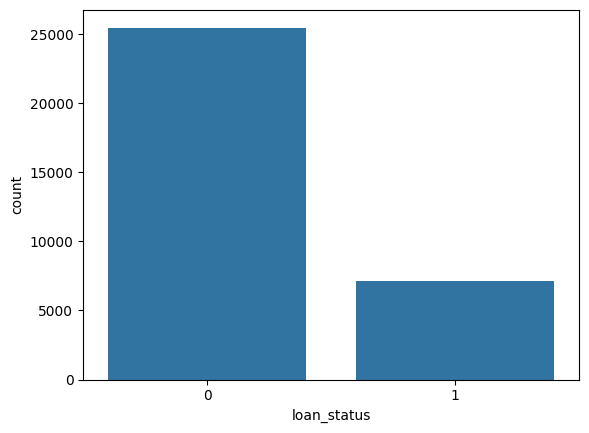

In [11]:
sns.countplot(x=df["loan_status"],data=df)

# Outlier check
Look for values that seem impossible, like age 144.
These are signs of bad data entries.

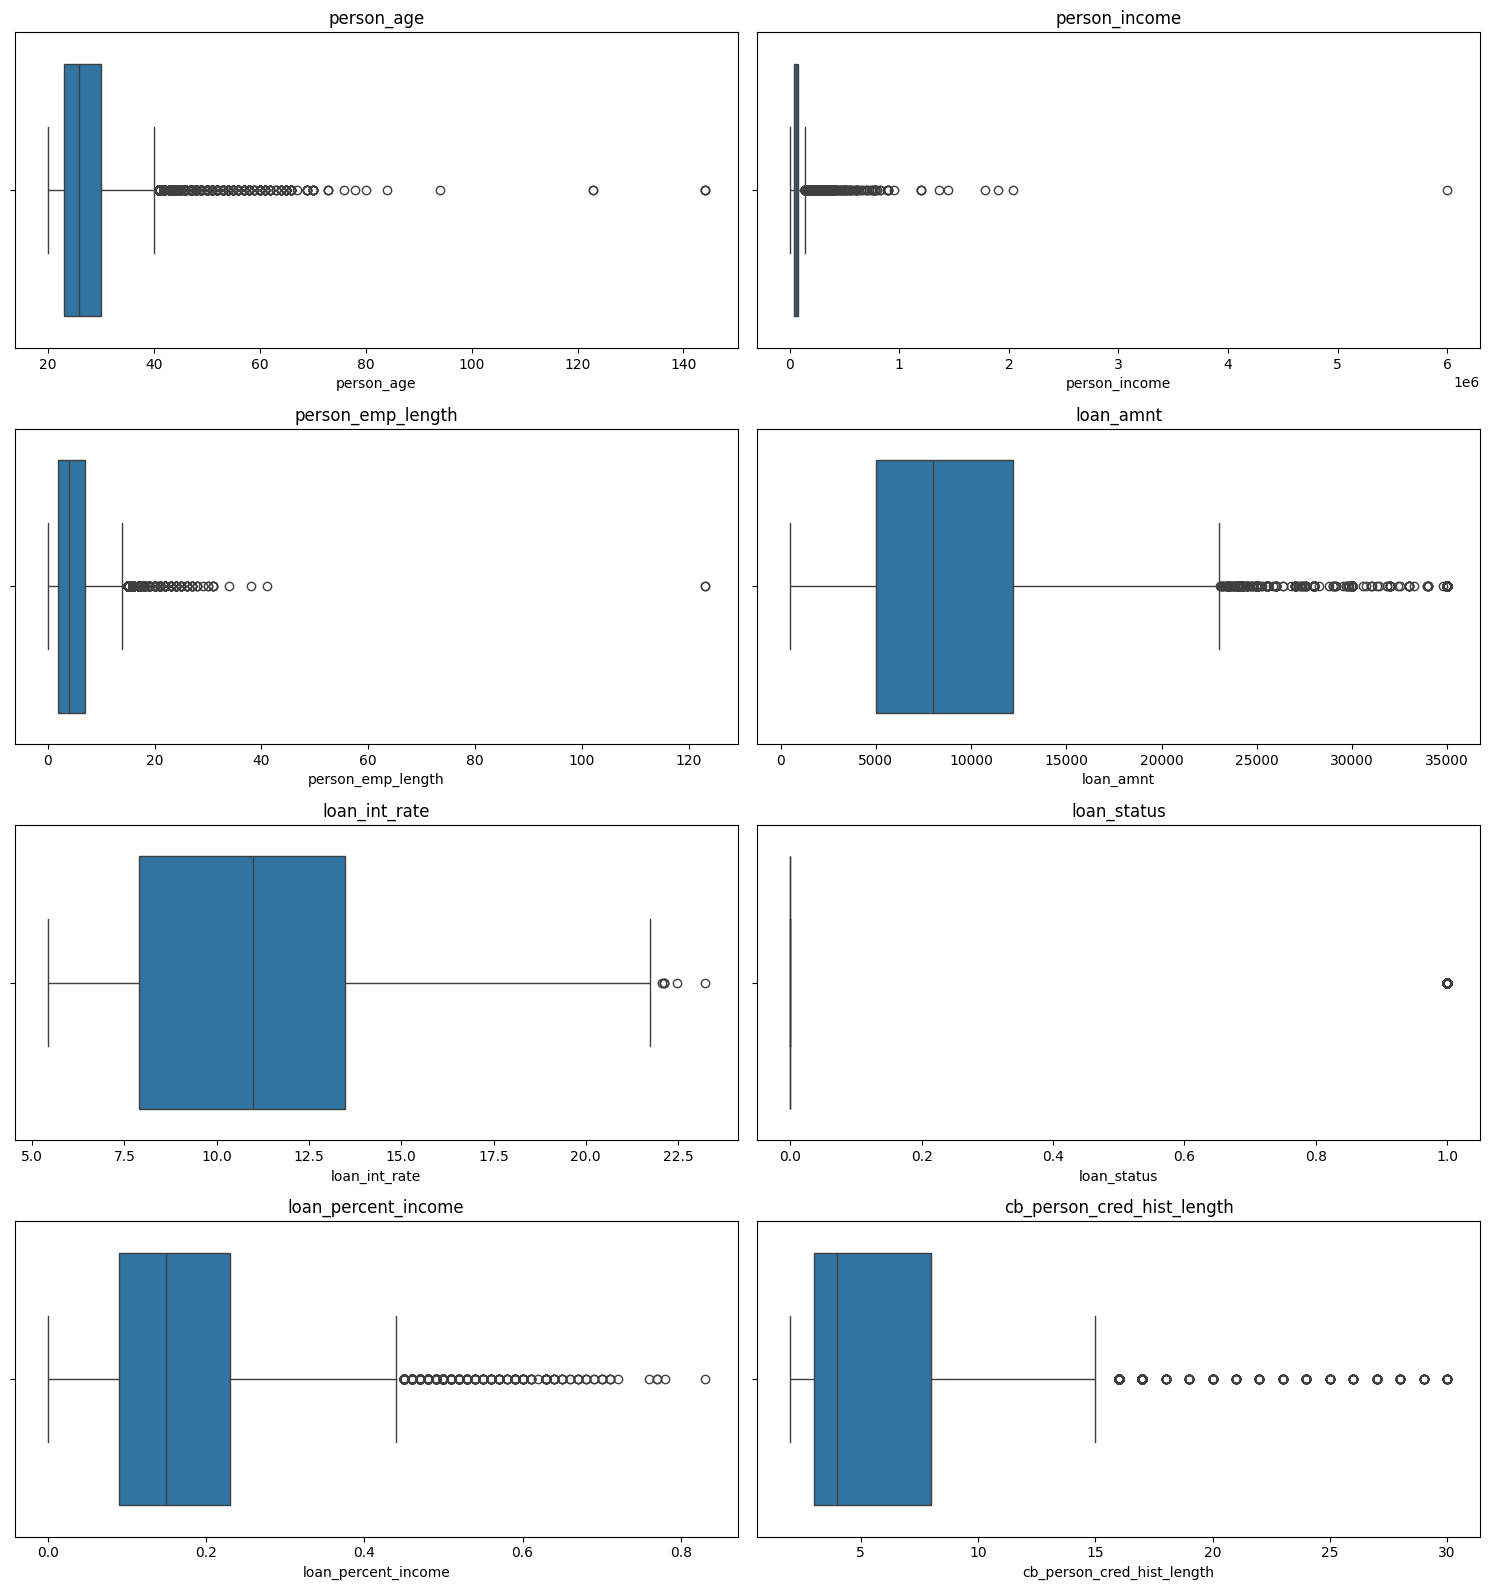

In [12]:
numerical_cols = df.select_dtypes(include=np.number).columns
n = len(numerical_cols)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)


for i in range(n, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [13]:
print((df['person_age'] > 100).sum())

5


In [14]:

print((df['person_emp_length'] > 60).sum())

2


In [15]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000



# Correlation check
See how strongly features are related to each other.
This helps us spot repeated or linked information.

<Axes: >

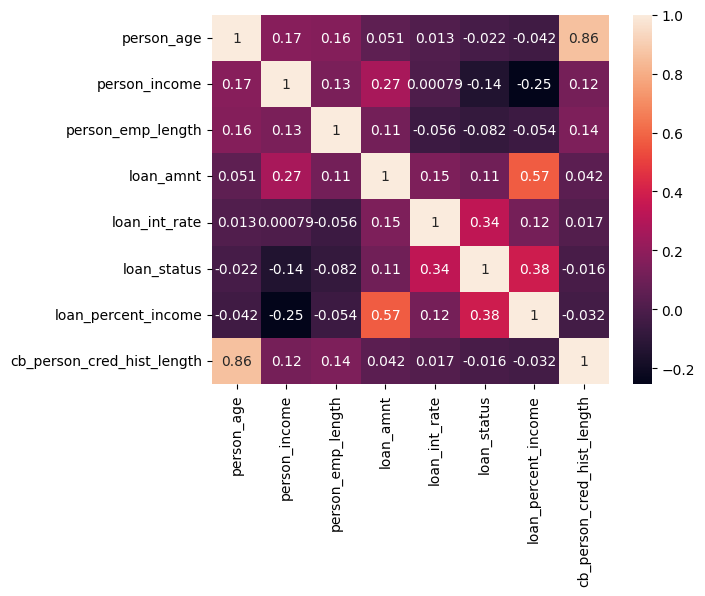

In [16]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# 3. Data Validation & Outlier Handling
Here we clean the data properly.
We remove duplicate rows.
We remove rows with an impossible age or work experience.
We remove rows with zero or negative income and loan amount.
We check if the interest rate looks realistic.
We also flag rows where numbers don't add up correctly.

In [17]:
df_copy=df.copy()

In [18]:
print(f'Before dropping duplicates row count is {df_copy.shape[0]}')
df_copy.drop_duplicates(inplace=True)
print(f'After dropping duplicates row count is {df_copy.shape[0]}')

Before dropping duplicates row count is 32581
After dropping duplicates row count is 32416


In [19]:
df.copy=df_copy[df_copy['person_age'] >=18]
df.copy=df_copy[df_copy['person_age'] <=100]


In [20]:
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]


In [21]:
df_copy = df_copy[df_copy['loan_amnt'] > 0]


In [22]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [23]:
print(f'Minimum rate of intrest is { df['loan_int_rate'].min()}')
print(f'Maximum rate of intrest is { df['loan_int_rate'].max()}')


Minimum rate of intrest is 5.42
Maximum rate of intrest is 23.22


In [24]:
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# 4. Features, Target & Train-Test Split
We separate the data into input features and the target.
The target is whether the applicant defaulted or not.
We split the data into a training part and a testing part.
The model learns from the training part only.

In [25]:
X=df_copy.drop('loan_status',axis=1)
y=df_copy['loan_status']


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:

numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# 5. Handle Class Imbalance
Very few people actually default in this data.
If we ignore this, the model may just favor the majority class.
We give more importance to the minority class during training.
This helps the model actually learn to spot defaulters.

In [28]:
neg, pos = np.bincount(y_train)
scale_weigths = neg/pos
print(scale_weigths)

3.631955922865014


# 6. Data Preprocessing — Pipelines & Column Transformer
Raw data is not ready for a model directly.
We need to prepare numeric and text columns differently.
We will build a Pipeline for each model.
We will use ColumnTransformer to apply different steps to different columns.
# Preprocessing for Logistic Regression
Fill missing numeric values.
Scale numeric values, since this model is sensitive to scale.
Convert category columns into numbers using one-hot encoding.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


In [30]:
#LR Pipeline
preprocessor_lr=ColumnTransformer(
                transformers=[
                    ('num',Pipeline(steps=[
                        ('imputer',SimpleImputer(strategy='median')),
                        ('scaler',StandardScaler())]),
                     numeric_cols),
                    ('cat',Pipeline(steps=[
                        ('imputer',SimpleImputer(strategy='constant',fill_value="Missing")),
                        ('onehot',OneHotEncoder(handle_unknown='ignore'))]),
                     categorical_cols)])

# Preprocessing for XGBoost
Fill missing numeric values.
No scaling needed here, since tree models don't need it.
Convert category columns into numbers using one-hot encoding.

In [31]:
#XG Pipeline

preprocessor_xg=ColumnTransformer(
                transformers=[
                    ('num',Pipeline(steps=[
                        ('imputer',SimpleImputer(strategy='median')),
                        ]),
                     numeric_cols),
                    ('cat',Pipeline(steps=[
                        ('imputer',SimpleImputer(strategy='constant',fill_value="Missing")),
                        ('onehot',OneHotEncoder(handle_unknown='ignore'))]),
                     categorical_cols)])

In [32]:
from sklearn.model_selection import StratifiedKFold,cross_validate
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [33]:
scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [34]:

#Logistic Regression

lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])


In [35]:
#XG Boost

xgb_cv_pipeline=Pipeline(
    [
        ('preprocessor',preprocessor_xg),
        ('classifier',XGBClassifier(
            n_estimator=300,max_depth=5,
            leaning_rate=0.1,
            scale_pos_weight=scale_weigths,
            random_state=42))
    ]
)

In [36]:
xgb_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, leaning_rate=0.1,
                               learning_rate=None, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimator=300,
                               n_estimators=None, ...))])

In [37]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  #Metrics
  accuracy     = accuracy_score(y_test, y_pred)    #Overall model's preformance
  precision    = precision_score(y_test, y_pred)   #When the model says 1, how oftenly is it actually 1.
  recall       = recall_score(y_test, y_pred)      #of the actual 1 how many did the model catches
  f1           = f1_score(y_test, y_pred)          #Harmonic mean of precision and recall

  conf_matrix   = confusion_matrix(y_test, y_pred)
  class_report  = classification_report(y_test, y_pred)


  print(f"{model_name} Metrics:")
  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)


  #Plotting confusion matrix
  sns.heatmap(conf_matrix, annot=True, fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()


  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()



In [38]:
for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline),
                      ("XGBoost", xgb_cv_pipeline)]:
                       cv_results = cross_validate(pipe, X_train , y_train, cv=cv, scoring=scoring, n_jobs=-1)
                       print(cv_name)
                       print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
                       print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
                       print(f"Precision : {cv_results['test_precision'].mean()}")
                       print(f"Recall : {cv_results['test_recall'].mean()}")
                       print(f"F1 : {cv_results['test_f1'].mean()}")
                       print()



Logistic Regression
ROC-AUC : 0.8710170067231532
Accuracy : 0.8131317822389926
Precision : 0.5474802411322026
Recall : 0.7766758494031222
F1 : 0.6422191852036502

XGBoost
ROC-AUC : 0.9459123625697939
Accuracy : 0.9166964174137757
Precision : 0.8141735693066237
Recall : 0.795959595959596
F1 : 0.8048954004660581



In [39]:
from sklearn.pipeline import Pipeline
baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight= "balanced"))
])
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

In [40]:

xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1,
        scale_pos_weight=scale_weigths,random_state=42))
])
xg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Logistic Regression Metrics:
Accuracy : 0.82
Precision : 0.55
Recall : 0.79
F1 : 0.65

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      4944
           1       0.55      0.79      0.65      1362

    accuracy                           0.82      6306
   macro avg       0.74      0.81      0.76      6306
weighted avg       0.85      0.82      0.83      6306



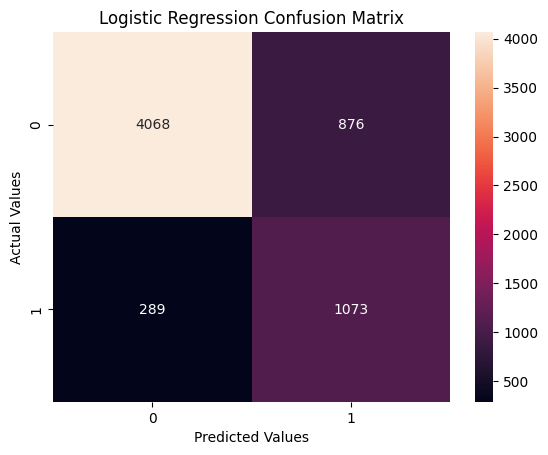

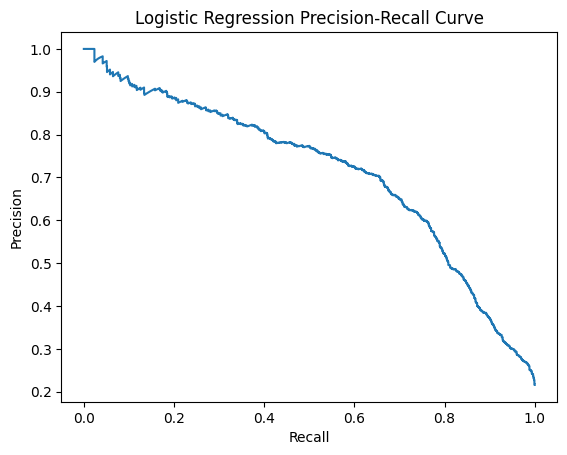

In [41]:
evaluate_model("Logistic Regression",baseline_model,X_test,y_test)

XGBoost Metrics:
Accuracy : 0.91
Precision : 0.80
Recall : 0.80
F1 : 0.80

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4944
           1       0.80      0.80      0.80      1362

    accuracy                           0.91      6306
   macro avg       0.87      0.87      0.87      6306
weighted avg       0.91      0.91      0.91      6306



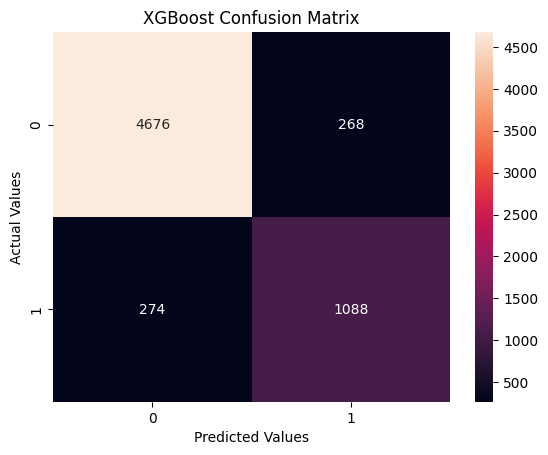

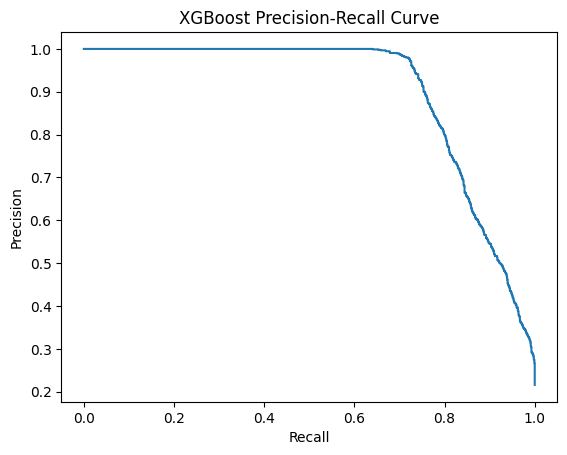

In [42]:
evaluate_model("XGBoost",xg_model,X_test,y_test)

In [43]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth" : randint(3,9),
    "classifier__learning_rate" : uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6,0.4), #Rows sampling
    "classifier__colsample_bytree" :uniform(0.6,0.4), #column sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0 , 5)
}
# lower gamma -> more splits -> complex tree -> higher overfitting risk
# higher gamma -> less splits ->  simpler tree -> low overfitting


In [44]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d8c84f37c50>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d8c898bfb60>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d8c84fec690>},
                   scoring='average_precision', verbose=1)

In [45]:
resultdf=pd.DataFrame(random_search.cv_results_)
resultdf

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__colsample_bytree,param_classifier__gamma,param_classifier__learning_rate,param_classifier__max_depth,param_classifier__min_child_weight,param_classifier__n_estimators,param_classifier__subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.551070,0.527048,0.129146,0.028272,0.843639,2.621436,0.413221,3,4,490,0.760750,{'classifier__colsample_bytree': 0.84363901331...,0.900595,0.891499,0.897790,0.906584,0.885643,0.896422,0.007252,77
1,0.810935,0.083123,0.049152,0.000891,0.692205,3.409720,0.269506,3,7,170,0.754986,{'classifier__colsample_bytree': 0.69220507845...,0.899270,0.893031,0.893455,0.900516,0.884086,0.894072,0.005826,104
2,1.343614,0.012980,0.072654,0.008529,0.659676,3.185347,0.375991,3,7,419,0.898530,{'classifier__colsample_bytree': 0.65967646194...,0.901309,0.897829,0.897826,0.906412,0.889513,0.898578,0.005516,43
3,1.664976,0.290993,0.091400,0.032421,0.684137,0.768427,0.132770,3,9,373,0.675002,{'classifier__colsample_bytree': 0.68413680837...,0.901239,0.894002,0.893790,0.899653,0.885007,0.894738,0.005702,97
4,1.607403,0.429286,0.093260,0.029152,0.920213,0.038942,0.442152,4,5,192,0.840715,{'classifier__colsample_bytree': 0.92021280701...,0.898092,0.893895,0.895704,0.903462,0.887919,0.895815,0.005094,85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,3.466061,0.351387,0.152041,0.003788,0.804107,1.948103,0.072438,8,6,590,0.757697,{'classifier__colsample_bytree': 0.80410693065...,0.904606,0.902817,0.904801,0.909890,0.891518,0.902726,0.006079,6
146,1.832621,0.443235,0.106741,0.038994,0.815615,1.140320,0.503303,5,6,253,0.711197,{'classifier__colsample_bytree': 0.81561468503...,0.889936,0.886557,0.890437,0.895008,0.878809,0.888149,0.005390,134
147,1.274499,0.297022,0.068055,0.022321,0.978830,4.967781,0.307384,5,6,242,0.806336,{'classifier__colsample_bytree': 0.97883022776...,0.901691,0.900127,0.897805,0.902170,0.888633,0.898086,0.004965,49
148,1.689880,0.014391,0.087080,0.013796,0.642203,4.946884,0.224691,4,9,544,0.827075,{'classifier__colsample_bytree': 0.64220290330...,0.901726,0.896833,0.898307,0.908339,0.890135,0.899068,0.005973,37


In [46]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.8441747977024326),
 'classifier__gamma': np.float64(0.18737623579435925),
 'classifier__learning_rate': np.float64(0.0678242047008764),
 'classifier__max_depth': 5,
 'classifier__min_child_weight': 5,
 'classifier__n_estimators': 497,
 'classifier__subsample': np.float64(0.9043021384114172)}

Logistic Regression Metrics:
Accuracy : 0.82
Precision : 0.55
Recall : 0.79
F1 : 0.65

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      4944
           1       0.55      0.79      0.65      1362

    accuracy                           0.82      6306
   macro avg       0.74      0.81      0.76      6306
weighted avg       0.85      0.82      0.83      6306



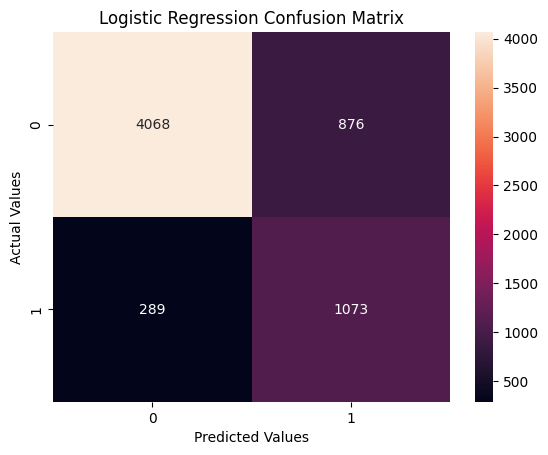

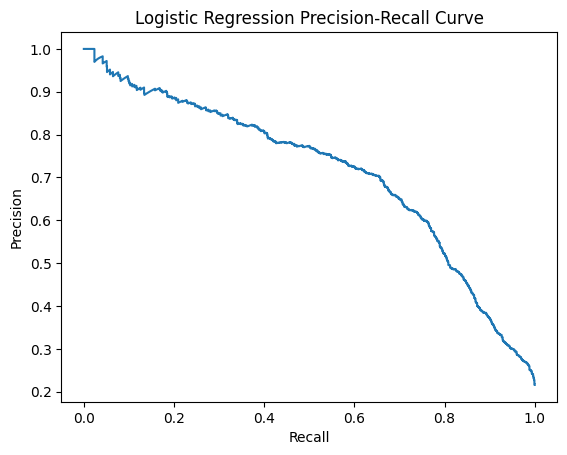

In [47]:
evaluate_model("Logistic Regression", baseline_model, X_test, y_test)

XGBoost Metrics:
Accuracy : 0.92
Precision : 0.82
Recall : 0.81
F1 : 0.81

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4944
           1       0.82      0.81      0.81      1362

    accuracy                           0.92      6306
   macro avg       0.88      0.88      0.88      6306
weighted avg       0.92      0.92      0.92      6306



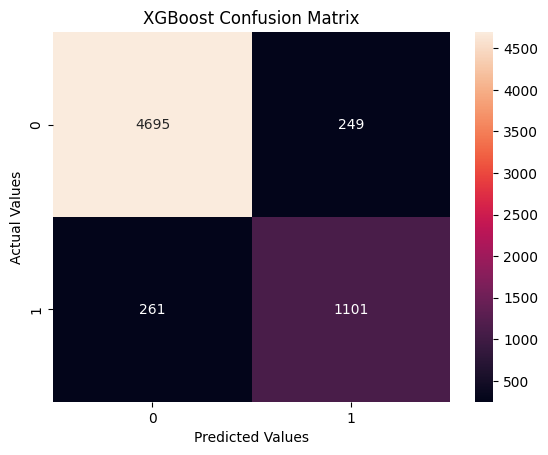

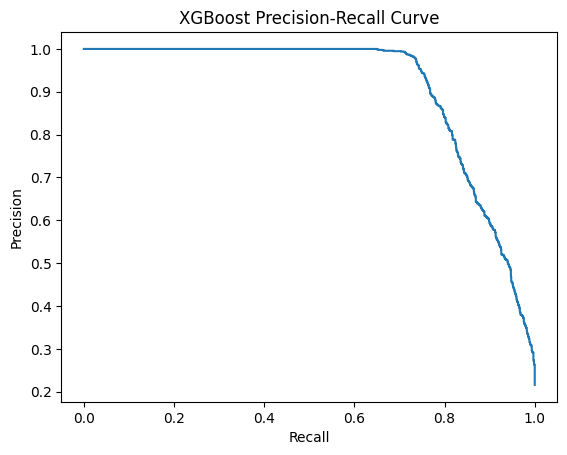

In [48]:
evaluate_model("XGBoost", random_search, X_test, y_test)


In [49]:

print(f"Score after performing Tunning {random_search.best_score_:.2f}")

Score after performing Tunning 0.91


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

XGBoost Metrics:
Used Threshold : 1.00
Accuracy : 0.78
Precision : 0.00
Recall : 0.00
F1 : 0.00

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4944
           1       0.00      0.00      0.00      1362

    accuracy                           0.78      6306
   macro avg       0.39      0.50      0.44      6306
weighted avg       0.61      0.78      0.69      6306



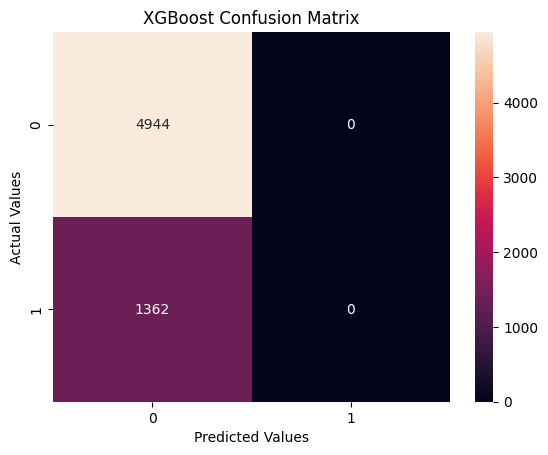

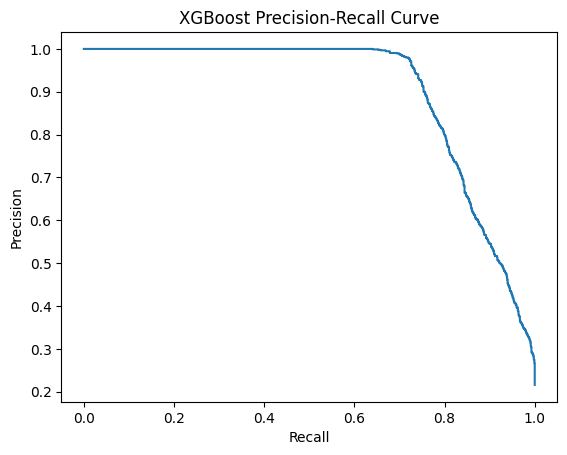

In [50]:

#Get the prob. of class 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:, 1]

#For each threshold calculate Precision and Recall
precisions, recalls , thresholds = precision_recall_curve(y_test, prob)


#Calculate F1 score for each threshold
f1 = 2 * (precisions-recalls) / (precisions + recalls + 1e-9)

#Get the threshold that produces the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

#Evaluate the XGBoost model using that threshold.
evaluate_model("XGBoost", xg_model, X_test, y_test, best_threshold)

In [51]:
#probabiltiy calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.0678242047008764),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=5,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=497,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [52]:
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]


In [55]:
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

In [56]:
actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins=10)

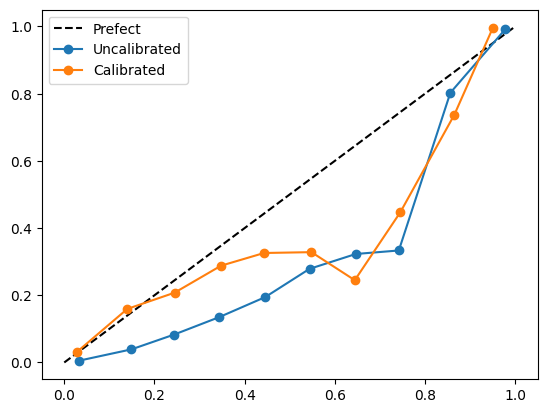

In [57]:


plt.plot([0,1], [0,1], 'k--', label="Prefect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)
plt.legend()

In [58]:
import shap

In [59]:
xgb_classifier = xg_model.named_steps['classifier']

In [60]:
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

In [61]:
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [62]:
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

In [63]:
explainer = shap.TreeExplainer(xgb_classifier)

In [64]:
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-1.2426843e-01, -4.6062568e-01,  6.4278513e-02, ...,
        -8.0010239e-03, -1.4844386e-02,  0.0000000e+00],
       [-4.0489540e-02, -3.1628144e-01,  9.2862323e-02, ...,
        -1.0323097e-02, -1.7884461e-02,  0.0000000e+00],
       [-3.8298738e-01, -5.2275288e-01,  1.0354085e-03, ...,
        -8.6352089e-03, -1.4110550e-02,  0.0000000e+00],
       ...,
       [-1.1068472e-01,  1.0742174e+00,  6.7671376e-01, ...,
        -7.5163748e-03,  1.7351389e-02,  0.0000000e+00],
       [ 1.2601131e-01,  1.6431303e-01,  5.6440376e-02, ...,
        -8.9768348e-03, -1.0607636e-02,  0.0000000e+00],
       [ 1.0705430e-01,  8.1132752e-01, -1.4280498e-01, ...,
        -7.8439750e-03, -1.4714407e-02,  0.0000000e+00]], dtype=float32)

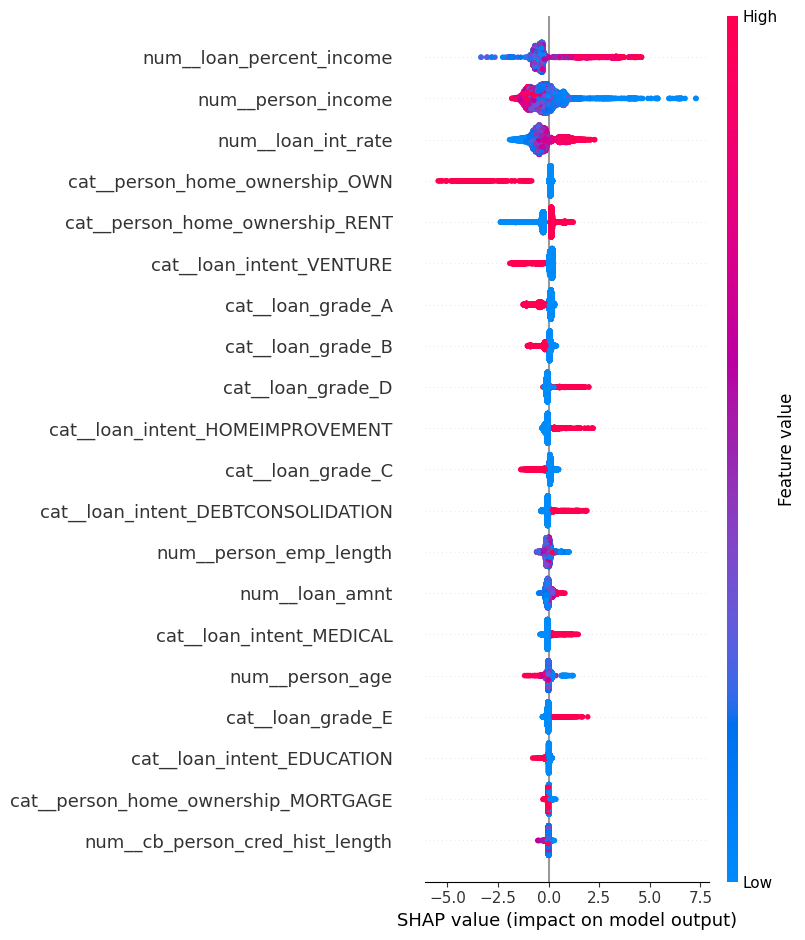

In [65]:

shap.summary_plot(shap_values, X_test_df)

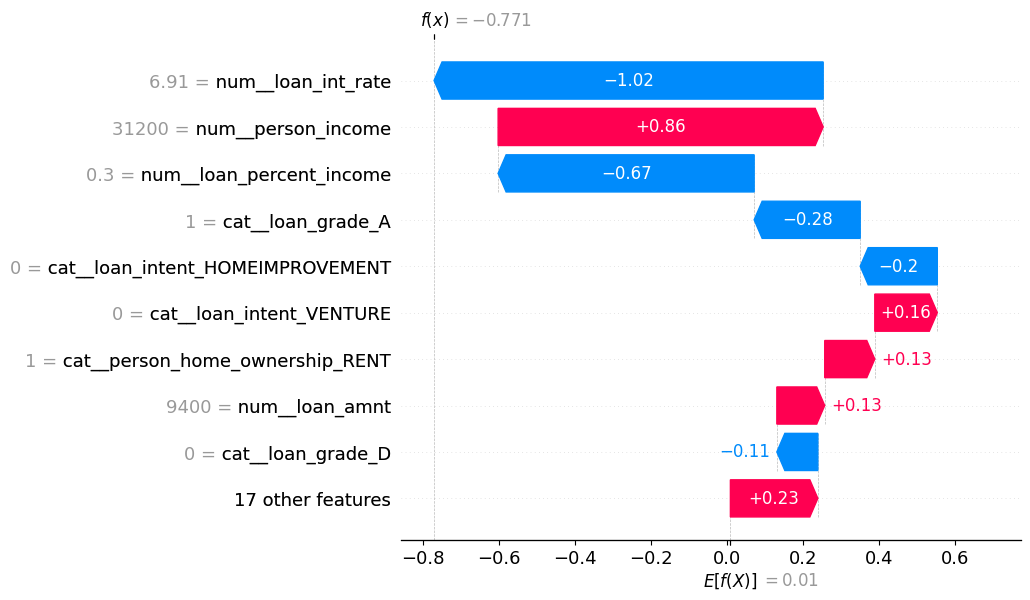

In [66]:

# 1. Pick one row to explain, e.g. the 5th applicant in the test set
row_index = 5

#2. Draw a waterfall plot showing how each feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

In [68]:
y_pred = random_search.predict(X_test)

In [71]:
cfm=confusion_matrix(y_test,y_pred)

In [84]:
print(f'False negative values are: {cfm[1, 0]}')
print(f'False positive values are: {cfm[0, 1]}')

False negative values are: 261
False positive values are: 249


In [86]:
import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [87]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']